# B — Partial Melting Pool Evolution: Impact-Induced Magma Ocean Dynamics

This notebook refines the **impact event classification** by identifying and tracking 
**partial melting pools** — regions of transient magma generation during collisions:

**Key steps:**
1. Load processed impact event data from C1 (global melting events classification)
2. Initialize partial melting process updater
   - Identifies conditions favoring **partial melting** (intermediate energy impacts)
   - Tracks magma pool evolution and cooling timescales
   - Distinguishes from **small impacts** (no melting) and **global melting** (complete liquidation)
3. Update partial melting event database with refined classifications
4. Visualize three-tier impact event hierarchy:
   - **Small impacts** (black dots): P = 0.6 × P_CMB, no melting
   - **Global melting** (orange dots): System-wide magma ocean
   - **Partial melting** (red stars): Localized melt pools, intermediate regime
5. Extract equilibrium pressure (P_equil) at each partial melting event
6. Visualize P-T-time evolution with event-type discrimination
7. Export refined classification to Excel

**Output:** `./Tables/{Model}_giant_impact.xlsx`

> **Key assumptions:**
> - Partial melting occurs in intermediate energy regime (between small & global impacts)
> - Melt pools are transient features lasting hours to days in model time
> - Pressure conditions determine solidus crossing and partial melting fraction
> - Partial melting pool dynamics follows crustal magma chamber evolution
>
> **Input:** `./Tables/{Model}_small_impact.xlsx` (pre-classified impact events)  
> **Output:** Three-tier event classification with partial melting pool tracking

**Physical model:**

The accretion impact spectrum is classified thermodynamically:

$$\text{Impact}_{\text{regime}} = \begin{cases}
\text{Small} & E < E_{\text{threshold,1}} \Rightarrow \text{no melting} \\
\text{Partial melting} & E_{\text{threshold,1}} \leq E < E_{\text{threshold,2}} \Rightarrow \text{melt fraction } f \in (0, 1) \\
\text{Global melting} & E \geq E_{\text{threshold,2}} \Rightarrow \text{magma ocean } f \approx 1
\end{cases}$$

Partial melting pools represent the **intermediate thermal regime** where:
- Pressure: $0.6 P_{\text{CMB}} < P < P_{\text{CMB}}$
- Temperature: crosses mantle solidus locally
- Melt fraction: $0 < f < 1$ (mixed solid-liquid)
- Timescale: rapid cooling over ~5 Myr

This notebook tracks where and when planets experienced **partial melting** during assembly.

In [1]:
# ============================================================================
# SETUP & CONFIGURATION
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys
import pathlib
from matplotlib.lines import Line2D

sys.path.append('../../src')
import accrediff as ad

# ── Plot style (Nature-style) ────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",       # 衬线字体
    "font.size": 12,              # 主体字体大小
    "axes.linewidth": 1,          # 坐标轴线宽
    "axes.labelsize": 14,         # 坐标轴标签大小
    "xtick.labelsize": 12,        # x 轴刻度字体
    "ytick.labelsize": 12,        # y 轴刻度字体
    "xtick.direction": "in",      # 刻度线朝内
    "ytick.direction": "in",
    "xtick.top": False,           # 去掉上方刻度
    "ytick.right": False,         # 去掉右侧刻度
    "figure.dpi": 300             # 提高分辨率
})

# ── Partial melting configuration ────────────────────────────────
config = {
    'process': 'partial_melting',
    'regime': 'intermediate',     # Between small and global impacts
    'description': 'Localized magma pool generation from impact heating',
}

# ── Event color scheme ───────────────────────────────────────────
event_colors = {
    'small': 'black',             # No melting
    'global': 'orange',           # System-wide magma ocean
    'partial': 'red',             # Intermediate partial melting
}

event_markers = {
    'small': 'o',                 # Circle
    'global': 'o',                # Circle
    'partial': '*',               # Star (distinctive marker)
}

print("✅ Setup complete.")
print(f"Configuration:")
print(f"  Process              : {config['process']}")
print(f"  Regime               : {config['regime']}")
print(f"  Event color scheme   : {event_colors}")
print()

✅ Setup complete.
Configuration:
  Process              : partial_melting
  Regime               : intermediate
  Event color scheme   : {'small': 'black', 'global': 'orange', 'partial': 'red'}



---
## 1. Load Pre-Processed Impact Event Data

Load the output from C1 notebook containing classified impact events 
(**small** vs **global** melting) with their pressure-time trajectories.

**Input file:** `./Tables/{Model}_small_impact.xlsx`
- Multiple sheets (one per model/dataset)
- Columns: `Time`, `Mass`, `P_equil`, `target_id`, `events` ('small' or 'global')

**Processing chain:** Raw collision data → C1 (binary classification) → C2 (ternary + partial melting)

In [2]:
# ============================================================================
# SECTION 1: LOAD PRE-CLASSIFIED IMPACT EVENTS
# ============================================================================
Model = 'note_02'
data_name = Model+'_small_impact.xlsx'
base_path = './Tables/'
Path_accretion_history = os.path.join(base_path, data_name)

# ── Load all sheets from Excel ───────────────────────────────────
if not os.path.exists(Path_accretion_history):
    raise FileNotFoundError(f"Input file not found: {Path_accretion_history}")

D = pd.read_excel(Path_accretion_history, sheet_name=None)
title = Path_accretion_history[9:16]  # Extract filename for titles

print(f"✓ Loaded pre-processed impact events: {Path_accretion_history}")
print(f"  Available sheets      : {len(D)}")
print(f"  Sheet names           : {list(D.keys())}")
print()

# ── Inspect data structure ───────────────────────────────────────
sample_key = list(D.keys())[0]
sample_df = D[sample_key]

print(f"Sample dataset structure ({sample_key}):")
print(f"  Rows                  : {len(sample_df)}")
print(f"  Columns               : {list(sample_df.columns)}")

if 'events' in sample_df.columns:
    event_counts = sample_df['events'].value_counts()
    print(f"  Current event counts  :")
    for event_type, count in event_counts.items():
        print(f"    {event_type:10s}: {count:4d} ({count/len(sample_df)*100:5.1f}%)")

print()

✓ Loaded pre-processed impact events: ./Tables/note_02_small_impact.xlsx
  Available sheets      : 3
  Sheet names           : ['planets_1', 'planets_2', 'planets_3']

Sample dataset structure (planets_1):
  Rows                  : 142
  Columns               : ['Time', 'target_id', 'impactor_id', 'm_target', 'm_impactor', 'Mass', 'Impact ratio', 'events', 'P_equil', 'T_equil', 'k_mantle']
  Current event counts  :
    small     :  139 ( 97.9%)
    global    :    3 (  2.1%)



---
## 2. Identify and Mark Partial Melting Events

Apply partial melting detection algorithm to classify intermediate-energy impacts.

**Algorithm:**
1. For each impact event, analyze pressure-energy conditions
2. Identify events in **intermediate regime** (between small & global thresholds)
3. Classify as `'partial'` (new category)
4. Update event column: `'small'` | `'global'` | `'partial'` (ternary)
5. Track partial melting pool properties (pressure, duration, extent)

**Physical criteria:**
- Partial melting occurs when: pressure crosses mantle solidus
- Melt fraction $0 < f < 1$ distinguishes from complete melting (global)
- Recovery timescale ~5 Myr (same as global melting in this model)

In [3]:
# ============================================================================
# SECTION 2: UPDATE PARTIAL MELTING CLASSIFICATION
# ============================================================================

data_dict = {}

print(f"✓ Processing partial melting events:")
print()

for key in D.keys():
    df = D[key]
    
    # ── Update partial melting process ───────────────────────────
    # This function refines the binary (small/global) classification
    # to identify intermediate partial melting events
    df_updated = ad.update_partial_melting_process(df)
    
    # ── Store updated data ───────────────────────────────────────
    data_dict[key] = df_updated
    
    # ── Report statistics ────────────────────────────────────────
    n_small = (df_updated['events'] == 'small').sum()
    n_global = (df_updated['events'] == 'global').sum()
    n_partial = (df_updated['events'] == 'partial').sum()
    
    print(f"  {key:20s}: {len(df_updated):4d} total events | " +
          f"small: {n_small:3d} | global: {n_global:3d} | partial: {n_partial:3d}")

print()

✓ Processing partial melting events:

  planets_1           :  142 total events | small: 139 | global:   2 | partial:   1
  planets_2           :   96 total events | small:  84 | global:   9 | partial:   3
  planets_3           :   26 total events | small:  26 | global:   0 | partial:   0



---
## 3a. Visualize Mass Evolution with Three-Tier Event Classification

Plot planetary mass over time, color-coded by refined impact event type:
- **Black dots** = Small impact events (no melting)
- **Orange dots** = Global melting events (complete magma ocean)
- **Red stars** = Partial melting events (localized melt pools)
- **Grey line** = Continuous mass evolution
- **Log time scale** for better resolution of early assembly phase

**Interpretation:**
- Star clustering reveals when partial melting was most active
- Early growth phase (t < 1 Myr): dominance of small impacts
- Late accretion (t > 10 Myr): transition to fewer, larger global events

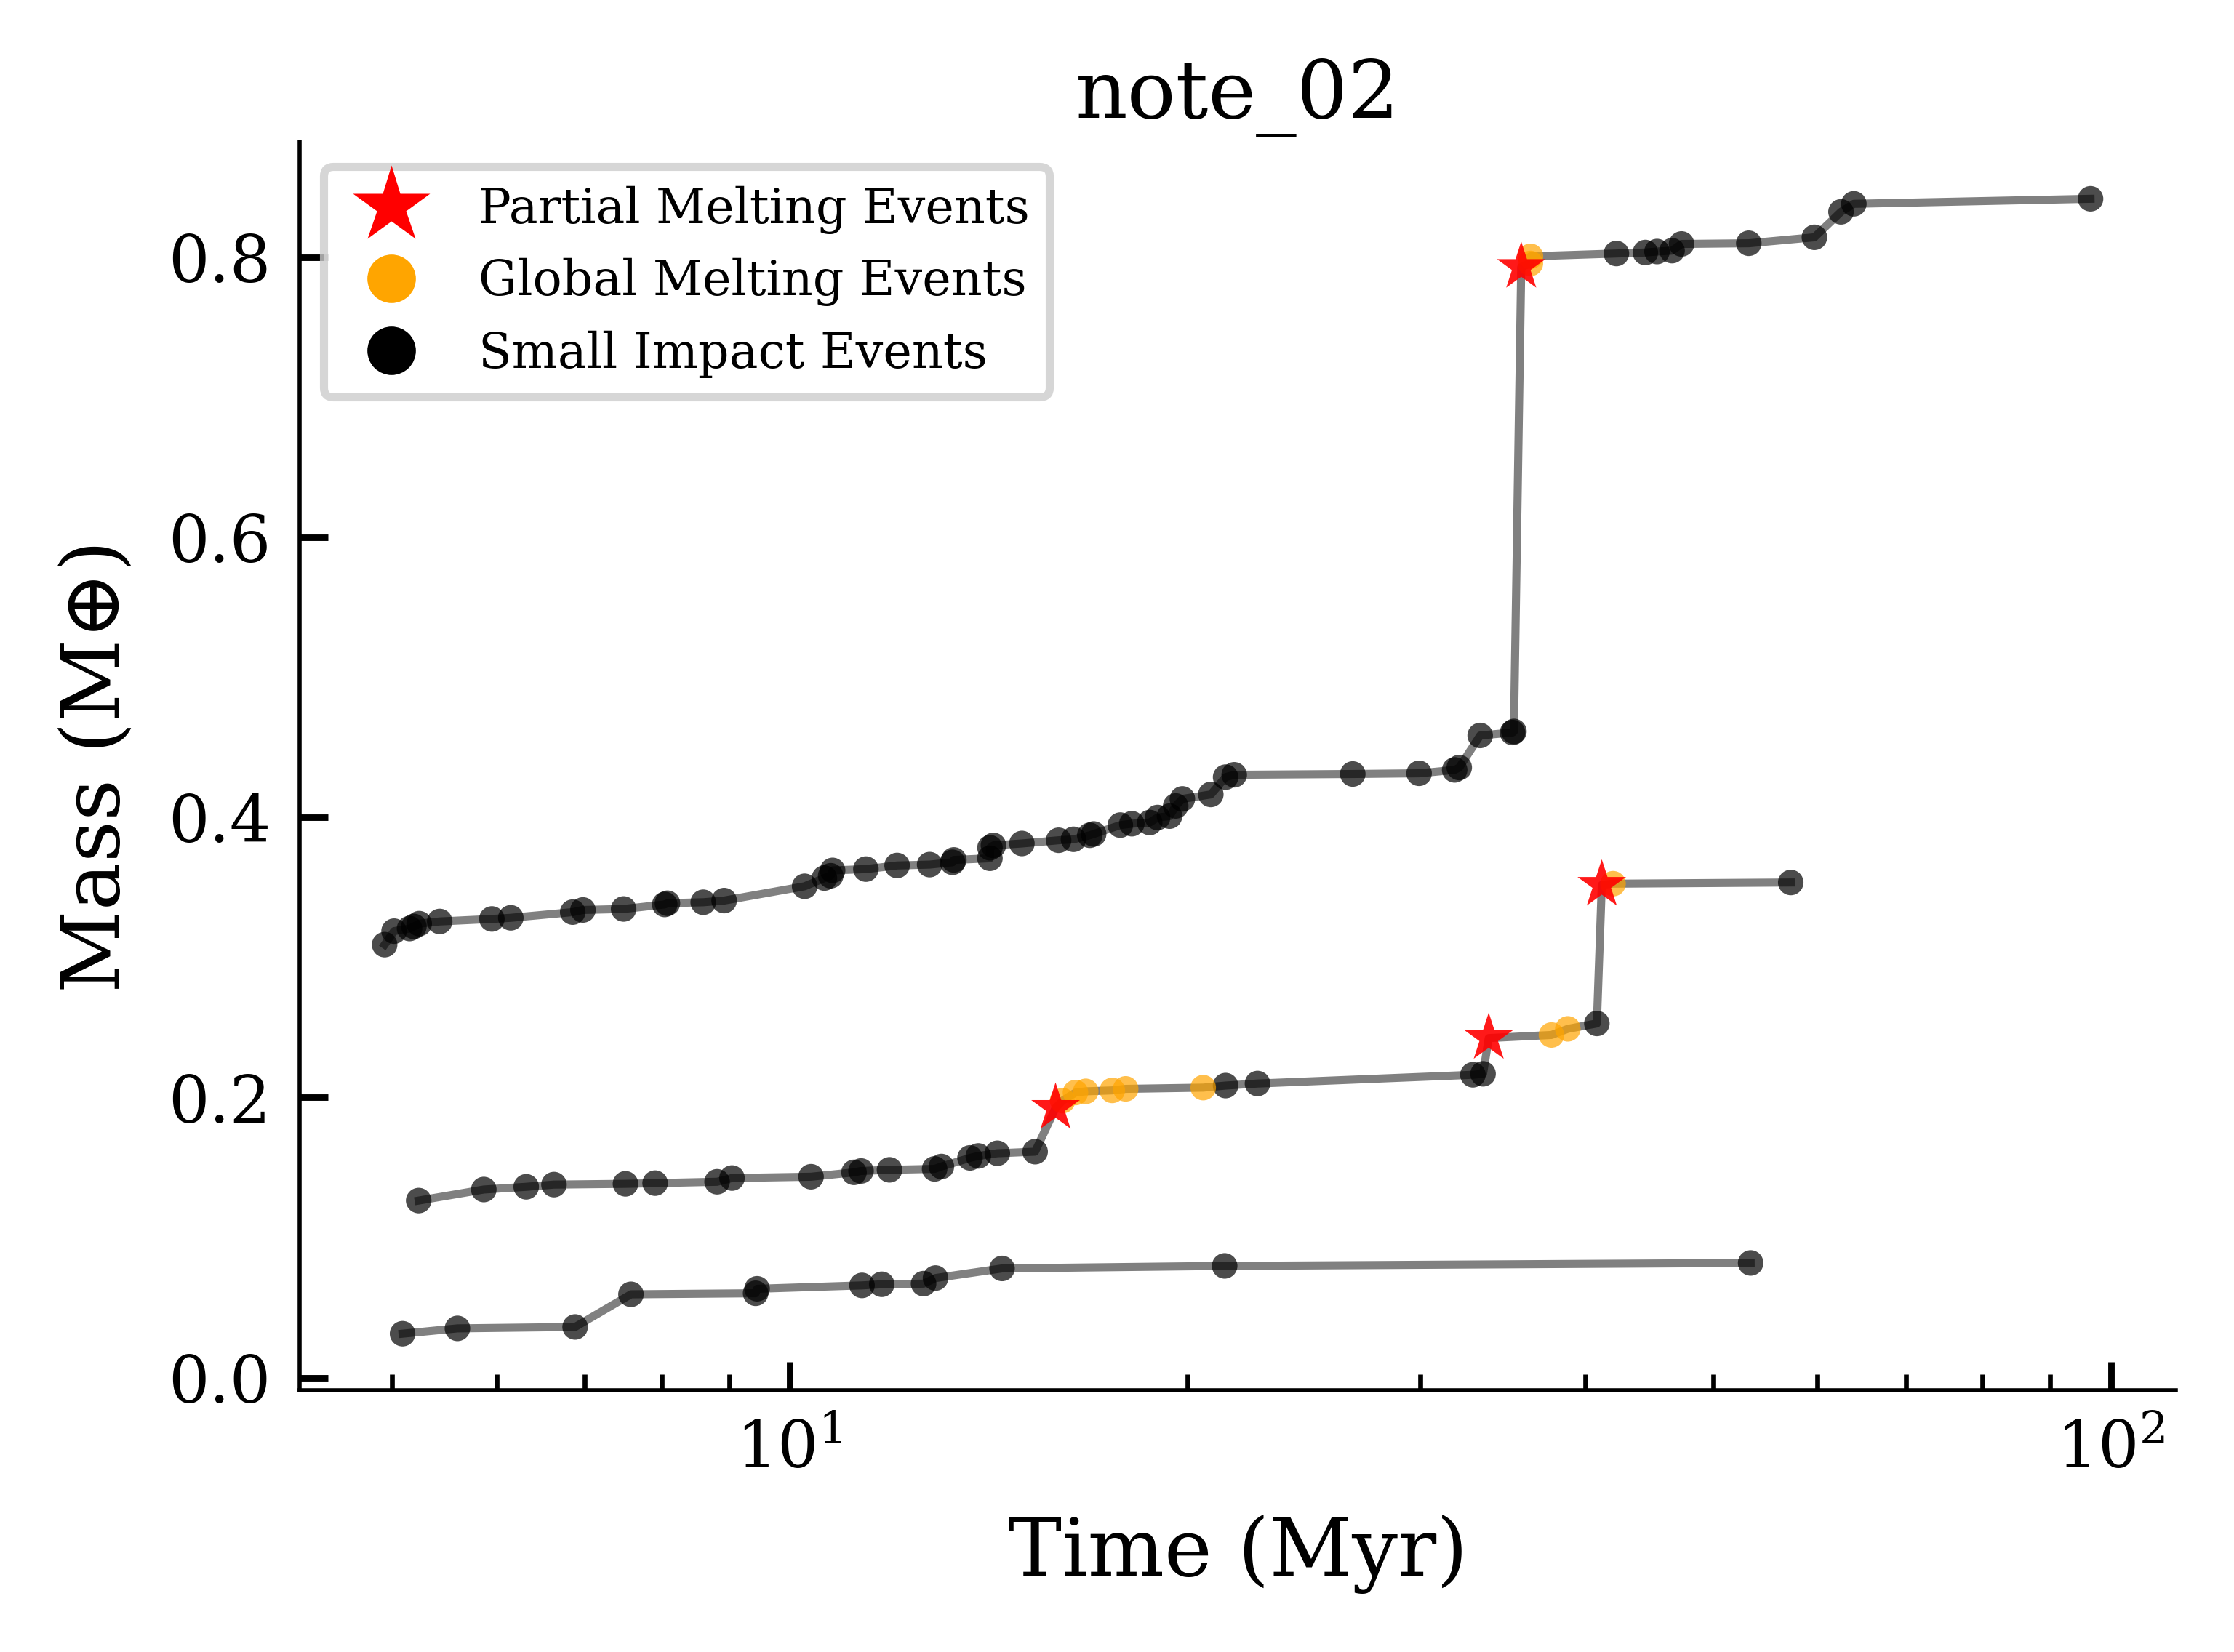

✓ Mass evolution plot displayed (log time scale)



In [4]:
# ============================================================================
# SECTION 3a: VISUALIZATION - MASS EVOLUTION (Three-Tier Classification)
# ============================================================================

plt.figure(figsize=(4, 3), dpi=800)

for i in data_dict.keys():
    df1 = data_dict[i]
    planet_id = df1['target_id'].iloc[-1]
    df_planet = df1[df1['target_id'] == planet_id]
    
    x = df_planet['Time']
    y = df_planet['Mass']
    
    # ── Create masks for each event type ─────────────────────────
    mask_small = df_planet['events'] == 'small'
    mask_global = df_planet['events'] == 'global'
    mask_partial = df_planet['events'] == 'partial'
    
    # ── Plot continuous evolution ────────────────────────────────
    plt.plot(x, y, c='grey', linewidth=1, zorder=3)
    
    # ── Plot small impacts (black circles) ────────────────────────
    plt.scatter(x[mask_small], y[mask_small], c='black', s=10, 
               alpha=0.7, edgecolors='none', zorder=4, label=None)
    
    # ── Plot global melting (orange circles) ─────────────────────
    plt.scatter(x[mask_global], y[mask_global], c='orange', s=10, 
               alpha=0.7, edgecolors='none', zorder=4, label=None)
    
    # ── Plot partial melting (red stars, prominent) ──────────────
    plt.scatter(x[mask_partial], y[mask_partial], c='red', s=40, 
               marker='*', alpha=0.9, edgecolors='none', zorder=5, label=None)

# ── Styling ──────────────────────────────────────────────────────
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# ── Logarithmic time scale for better early-time resolution ──────
ax.set_xscale('log')

# ── Axis labels ──────────────────────────────────────────────────
plt.title(f"{title}", fontsize=10, pad=3)
plt.xlabel("Time (Myr)", fontsize=10)
plt.ylabel("Mass (M⊕)", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# ── Legend with three event types ────────────────────────────────
legend_handles = [
    Line2D([0], [0], marker='*', color='w', label='Partial Melting Events',
           markerfacecolor='red', markersize=10, markeredgecolor='none'),
    Line2D([0], [0], marker='o', color='w', label='Global Melting Events',
           markerfacecolor='orange', markersize=6, markeredgecolor='none'),
    Line2D([0], [0], marker='o', color='w', label='Small Impact Events',
           markerfacecolor='black', markersize=6, markeredgecolor='none'),
]
plt.legend(handles=legend_handles, fontsize=6, loc='best', frameon=True)

plt.tight_layout()
plt.show()

print(f"✓ Mass evolution plot displayed (log time scale)")
print()

---
## 3b. Visualize Pressure Evolution with Three-Tier Event Classification

Plot equilibrium pressure (P_equil) over time, color-coded by refined event type:
- **Black dots** = Small impacts (P ≈ 0.6 × P_CMB, ~10-20 GPa)
- **Orange dots** = Global melting (P ≈ P_CMB, ~100+ GPa)
- **Red stars** = Partial melting (P intermediate, ~30-80 GPa)
- **Grey line** = Pressure evolution
- **Log time scale** reveals pressure thresholds for melting transitions

**Interpretation:**
- Pressure hierarchy: partial > small, but ≤ global
- Red star clustering defines partial melting pressure window
- Early impacts: low pressure, small events
- Late impacts: high pressure capable of triggering global melting

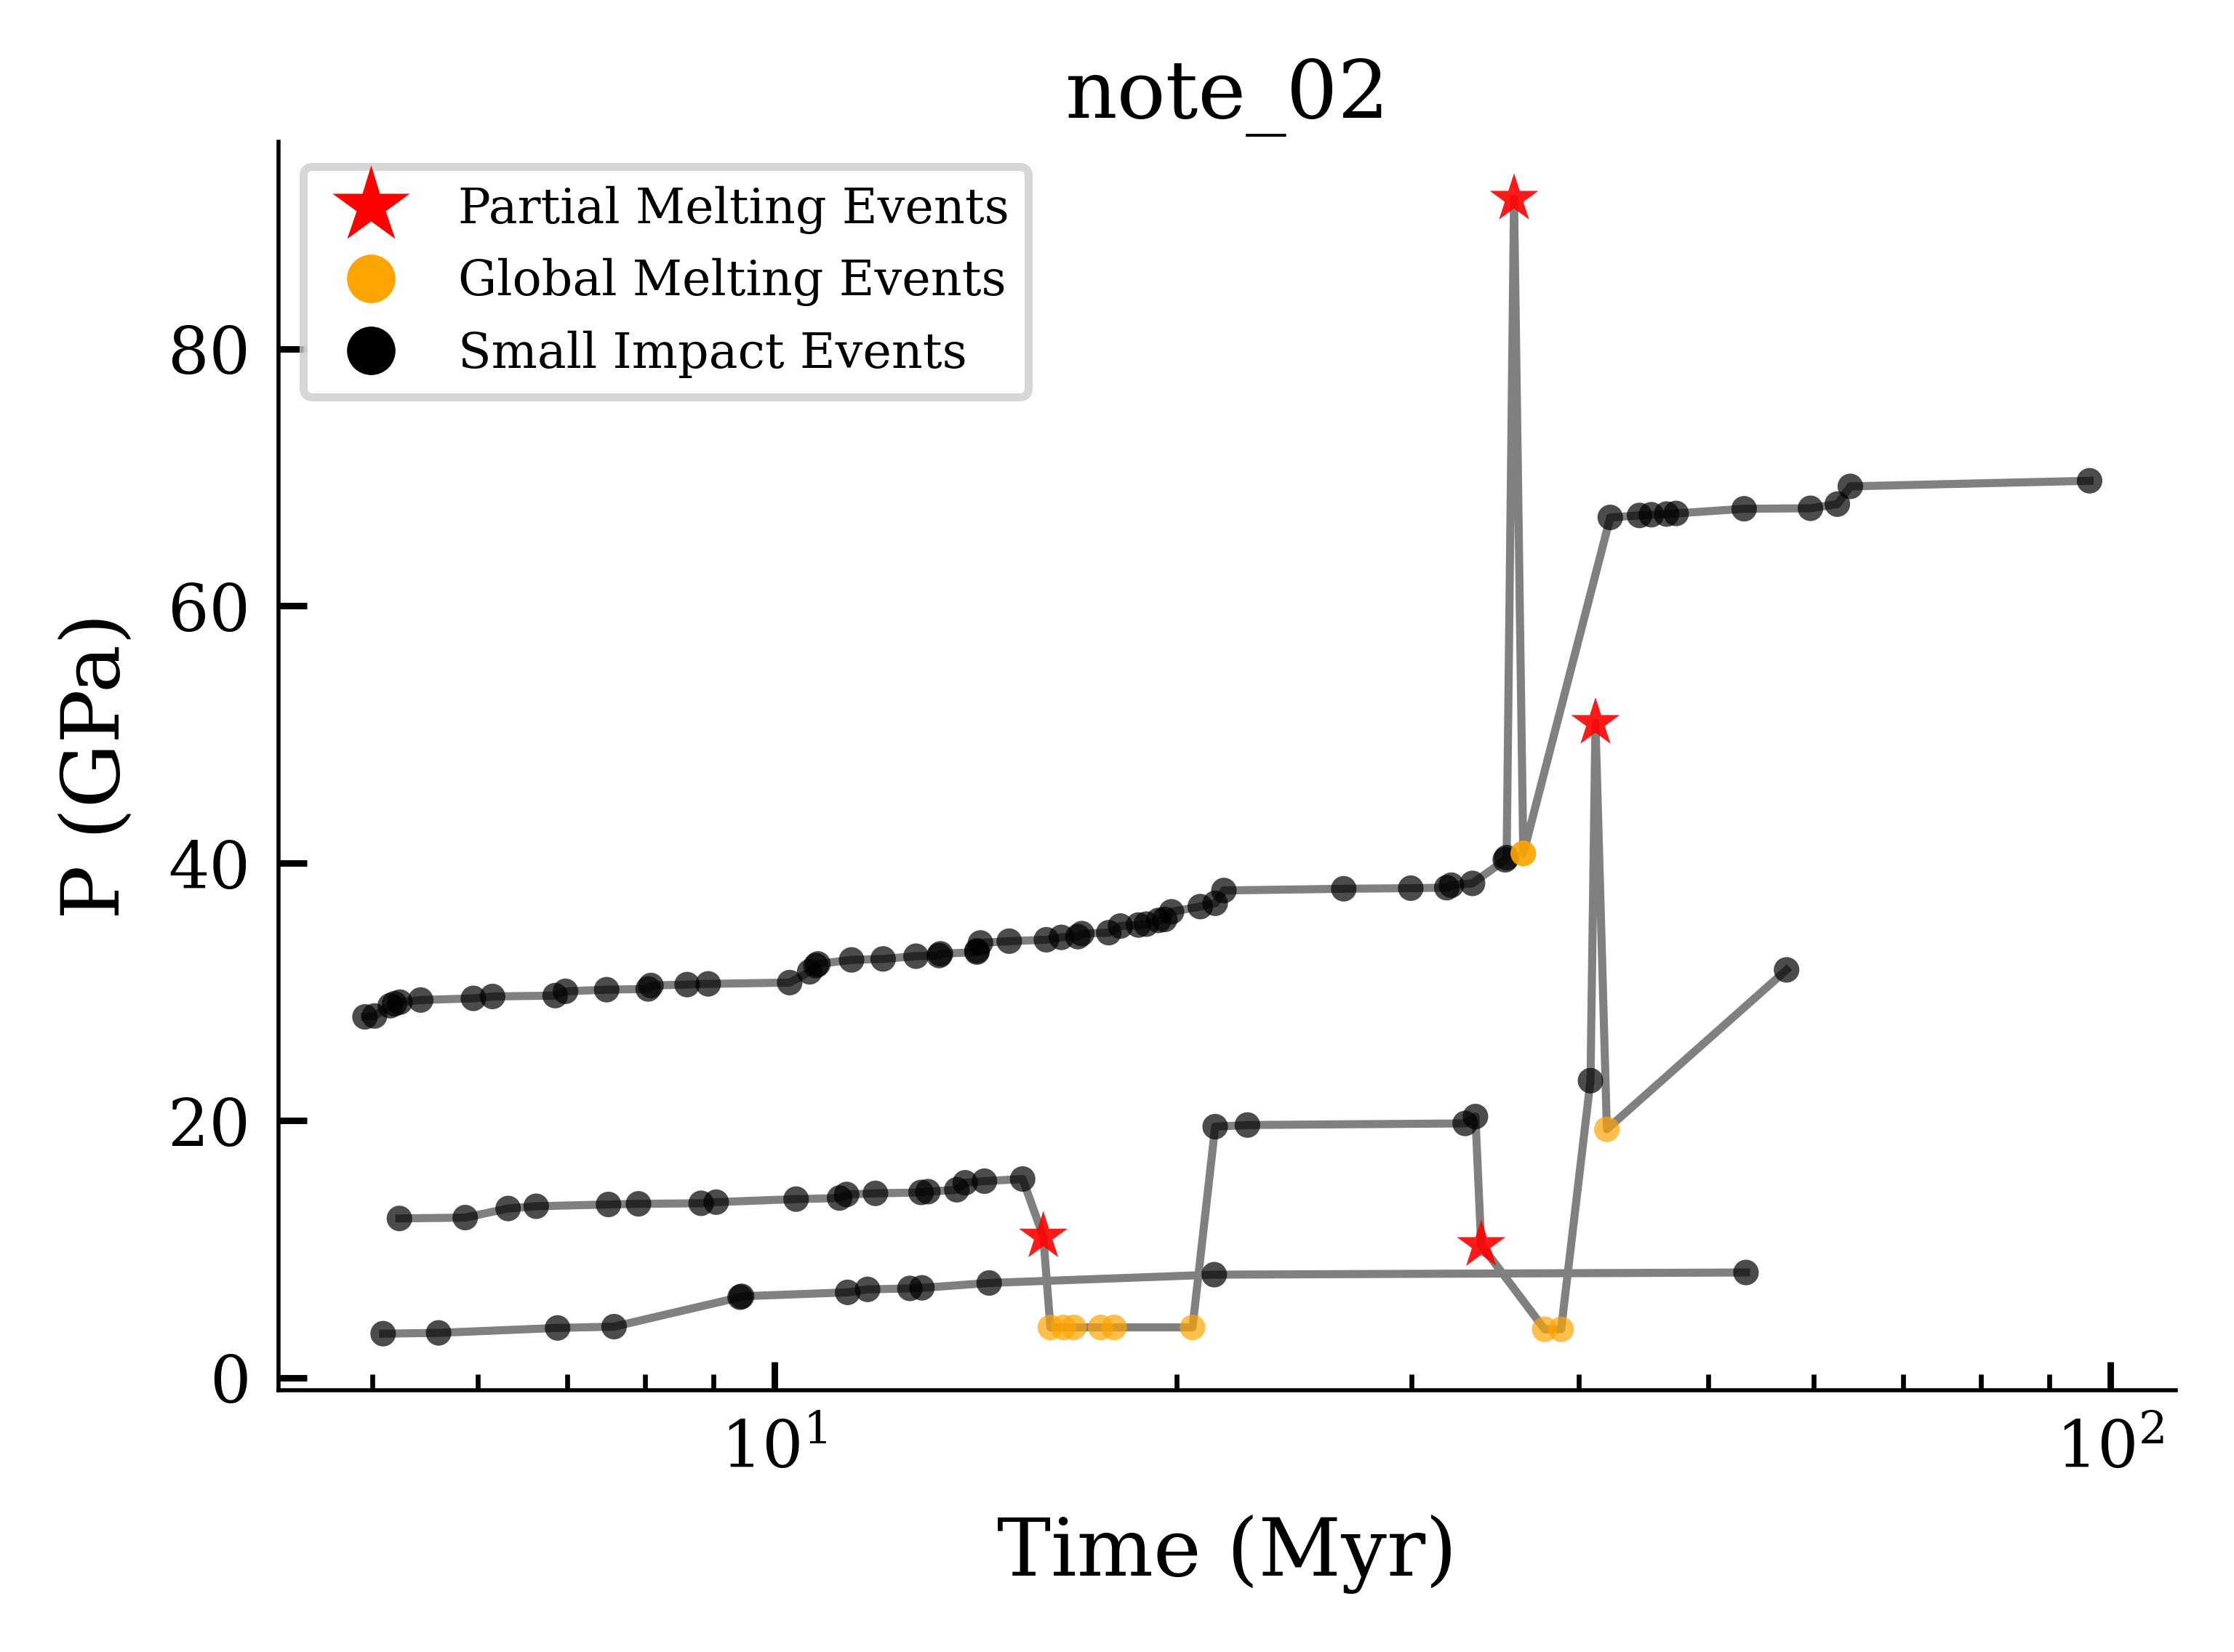

✓ Pressure evolution plot displayed (log time scale)



In [5]:
# ============================================================================
# SECTION 3b: VISUALIZATION - PRESSURE EVOLUTION (Three-Tier Classification)
# ============================================================================

plt.figure(figsize=(4, 3), dpi=800)

for i in data_dict.keys():
    df1 = data_dict[i]
    planet_id = df1['target_id'].iloc[-1]
    df_planet = df1[df1['target_id'] == planet_id]
    
    x = df_planet['Time']
    y = df_planet['P_equil']  # Key column: equilibrium pressure
    
    # ── Create masks for each event type ─────────────────────────
    mask_small = df_planet['events'] == 'small'
    mask_global = df_planet['events'] == 'global'
    mask_partial = df_planet['events'] == 'partial'
    
    # ── Plot continuous evolution ────────────────────────────────
    plt.plot(x, y, c='grey', linewidth=1, zorder=3)
    
    # ── Plot small impacts (black circles) ────────────────────────
    plt.scatter(x[mask_small], y[mask_small], c='black', s=10, 
               alpha=0.7, edgecolors='none', zorder=4, label=None)
    
    # ── Plot global melting (orange circles) ─────────────────────
    plt.scatter(x[mask_global], y[mask_global], c='orange', s=10, 
               alpha=0.7, edgecolors='none', zorder=4, label=None)
    
    # ── Plot partial melting (red stars, prominent) ──────────────
    plt.scatter(x[mask_partial], y[mask_partial], c='red', s=40, 
               marker='*', alpha=0.9, edgecolors='none', zorder=5, label=None)

# ── Styling ──────────────────────────────────────────────────────
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# ── Logarithmic time scale ───────────────────────────────────────
ax.set_xscale('log')

# ── Axis labels ──────────────────────────────────────────────────
plt.title(f"{title}", fontsize=10, pad=3)
plt.xlabel("Time (Myr)", fontsize=10)
plt.ylabel("P (GPa)", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# ── Legend ───────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], marker='*', color='w', label='Partial Melting Events',
           markerfacecolor='red', markersize=10, markeredgecolor='none'),
    Line2D([0], [0], marker='o', color='w', label='Global Melting Events',
           markerfacecolor='orange', markersize=6, markeredgecolor='none'),
    Line2D([0], [0], marker='o', color='w', label='Small Impact Events',
           markerfacecolor='black', markersize=6, markeredgecolor='none'),
]
plt.legend(handles=legend_handles, fontsize=6, loc='best', frameon=True)

plt.tight_layout()
plt.show()

print(f"✓ Pressure evolution plot displayed (log time scale)")
print()

---
## 4. Export Refined Impact Classification to Excel

Save all datasets with three-tier event classification to Excel file.
This preserves the complete partial melting pool history for downstream analysis 
of magma ocean dynamics, compositional mixing, and thermal evolution.

**Output structure:**
- One sheet per original dataset (key from D)
- All original columns retained
- Updated `events` column: 'small' | 'global' | 'partial'
- New columns from partial melting update (if applicable)

**Comparison:**
| File | Classification | Use case |
|------|-----------------|----------|
| {Model}_small_impact.xlsx | Binary (small/global) | Overall impact taxonomy |
| {Model}_giant_impact.xlsx | Ternary (small/global/partial) | Magma pool dynamics |

In [6]:
# ============================================================================
# SECTION 4: EXPORT REFINED CLASSIFICATION
# ============================================================================

save_dir = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)
save_file = f'./Tables/{Model}_giant_impact.xlsx'

# ── Create output directory if needed ────────────────────────────
os.makedirs(os.path.dirname(save_file), exist_ok=True)

# ── Write all datasets to Excel with new classification ─────────
with pd.ExcelWriter(save_file) as writer:
    for key, df in data_dict.items():
        df.to_excel(writer, sheet_name=key, index=False)

print(f"✅ Exported: {save_file}")
print(f"  Sheets    : {len(data_dict)}")
print(f"  Sheet names: {list(data_dict.keys())}")
print()

# ── Verify file size and content ─────────────────────────────────
import os as os_check
file_size_mb = os.path.getsize(save_file) / (1024 ** 2)
print(f"  File size : {file_size_mb:.2f} MB")
print()

✅ Exported: ./Tables/note_02_giant_impact.xlsx
  Sheets    : 3
  Sheet names: ['planets_1', 'planets_2', 'planets_3']

  File size : 0.03 MB



---
## 5. Load and Verify Refined Classification

Reload the Excel file to verify export quality and inspect the 
three-tier event classification with emphasis on partial melting pool characteristics.

In [7]:
# ============================================================================
# SECTION 5: VERIFICATION & DATA INSPECTION
# ============================================================================

# ── Reload exported file ─────────────────────────────────────────
df_dict = pd.read_excel(save_file, sheet_name=None)

print(f"✓ Verification: Reloaded {save_file}")
print(f"  Sheets loaded: {len(df_dict)}")
print(f"  Sheet names  : {list(df_dict.keys())}")
print()

# ── Inspect a sample sheet with detailed statistics ──────────────
sample_sheet = list(df_dict.keys())[0]
df_sample = df_dict[sample_sheet]

print(f"Sample sheet analysis ({sample_sheet}):")
print(f"  Total rows     : {len(df_sample)}")
print(f"  Total columns  : {len(df_sample.columns)}")
print(f"  Columns        : {list(df_sample.columns)}")
print()

# ── Three-tier event statistics ──────────────────────────────────
if 'events' in df_sample.columns:
    event_counts = df_sample['events'].value_counts()
    event_pcts = (event_counts / len(df_sample) * 100).round(1)
    
    print(f"Event classification summary:")
    for event_type in ['small', 'global', 'partial']:
        count = event_counts.get(event_type, 0)
        pct = event_pcts.get(event_type, 0)
        print(f"  {event_type:10s}: {count:4d} ({pct:5.1f}%)")
    print()

# ── Partial melting event detail analysis ────────────────────────
df_partial = df_sample[df_sample['events'] == 'partial']

if len(df_partial) > 0:
    print(f"Partial melting pool characterization ({len(df_partial)} events):")
    
    if 'Time' in df_partial.columns:
        print(f"  Time range     : {df_partial['Time'].min():.2f} - {df_partial['Time'].max():.2f} Myr")
    
    if 'P_equil' in df_partial.columns:
        print(f"  Pressure range : {df_partial['P_equil'].min():.2f} - {df_partial['P_equil'].max():.2f} GPa")
    
    if 'Mass' in df_partial.columns:
        print(f"  Mass range     : {df_partial['Mass'].min():.4f} - {df_partial['Mass'].max():.4f} M⊕")
    
    print()
else:
    print(f"⚠ Warning: No partial melting events identified in {sample_sheet}")
    print()

✓ Verification: Reloaded ./Tables/note_02_giant_impact.xlsx
  Sheets loaded: 3
  Sheet names  : ['planets_1', 'planets_2', 'planets_3']

Sample sheet analysis (planets_1):
  Total rows     : 142
  Total columns  : 11
  Columns        : ['Time', 'target_id', 'impactor_id', 'm_target', 'm_impactor', 'Mass', 'Impact ratio', 'events', 'P_equil', 'T_equil', 'k_mantle']

Event classification summary:
  small     :  139 ( 97.9%)
  global    :    2 (  1.4%)
  partial   :    1 (  0.7%)

Partial melting pool characterization (1 events):
  Time range     : 35.79 - 35.79 Myr
  Pressure range : 91.65 - 91.65 GPa
  Mass range     : 0.7929 - 0.7929 M⊕



---
## 6. Extract and Analyze Specific Event Types

Filter and examine subsets of each event type for detailed characterization.

**Analysis targets:**
- **Global melting events** → High-energy impacts, magma ocean conditions
- **Partial melting events** → Intermediate regime, mixed melt-solid state
- **Event transitions** → When system crossed melting thresholds

In [8]:
# ============================================================================
# SECTION 6: TARGETED EVENT ANALYSIS
# ============================================================================

# ── Extract global melting events ────────────────────────────────
df_global = df_dict[sample_sheet][df_dict[sample_sheet]['events'] == 'global']

print(f"✓ Global melting event subset ({sample_sheet}):")
print(f"  Count        : {len(df_global)} events")

if len(df_global) > 0 and 'P_equil' in df_global.columns:
    print(f"  Pressure avg : {df_global['P_equil'].mean():.2f} GPa " +
          f"(range: {df_global['P_equil'].min():.2f}-{df_global['P_equil'].max():.2f} GPa)")
    
    if 'Mass' in df_global.columns:
        print(f"  Mass avg     : {df_global['Mass'].mean():.4f} M⊕")

print()

# ── Extract partial melting events ───────────────────────────────
df_partial_detail = df_dict[sample_sheet][df_dict[sample_sheet]['events'] == 'partial']

print(f"✓ Partial melting event subset ({sample_sheet}):")
print(f"  Count        : {len(df_partial_detail)} events")

if len(df_partial_detail) > 0 and 'P_equil' in df_partial_detail.columns:
    print(f"  Pressure avg : {df_partial_detail['P_equil'].mean():.2f} GPa " +
          f"(range: {df_partial_detail['P_equil'].min():.2f}-{df_partial_detail['P_equil'].max():.2f} GPa)")
    
    if 'Mass' in df_partial_detail.columns:
        print(f"  Mass avg     : {df_partial_detail['Mass'].mean():.4f} M⊕")
        print(f"  Mass range   : {df_partial_detail['Mass'].min():.4f}-{df_partial_detail['Mass'].max():.4f} M⊕")

print()

# ── Extract small impact events ──────────────────────────────────
df_small_detail = df_dict[sample_sheet][df_dict[sample_sheet]['events'] == 'small']

print(f"✓ Small impact event subset ({sample_sheet}):")
print(f"  Count        : {len(df_small_detail)} events")

if len(df_small_detail) > 0 and 'P_equil' in df_small_detail.columns:
    print(f"  Pressure avg : {df_small_detail['P_equil'].mean():.2f} GPa " +
          f"(range: {df_small_detail['P_equil'].min():.2f}-{df_small_detail['P_equil'].max():.2f} GPa)")

print()

✓ Global melting event subset (planets_1):
  Count        : 2 events
  Pressure avg : 40.77 GPa (range: 40.77-40.77 GPa)
  Mass avg     : 0.7980 M⊕

✓ Partial melting event subset (planets_1):
  Count        : 1 events
  Pressure avg : 91.65 GPa (range: 91.65-91.65 GPa)
  Mass avg     : 0.7929 M⊕
  Mass range   : 0.7929-0.7929 M⊕

✓ Small impact event subset (planets_1):
  Count        : 139 events
  Pressure avg : 19.93 GPa (range: 0.09-69.74 GPa)



---
## 7. Summary and Workflow Statistics

Generate comprehensive summary of the partial melting analysis pipeline.

In [9]:
# ============================================================================
# SECTION 7: WORKFLOW SUMMARY
# ============================================================================

print("=" * 80)
print("WORKFLOW SUMMARY: PARTIAL MELTING POOL ANALYSIS")
print("=" * 80)
print()

print(f"Input configuration:")
print(f"  Input file            : {Path_accretion_history}")
print(f"  Process               : {config['process']}")
print(f"  Thermal regime        : {config['regime']}")
print(f"  Description           : {config['description']}")
print()

print(f"Data processing:")
print(f"  Datasets processed    : {len(data_dict)}")
print(f"  Total events analyzed : {sum(len(df) for df in data_dict.values())}")
print()

# Aggregate statistics across all datasets
total_small = 0
total_global = 0
total_partial = 0

for df in data_dict.values():
    if 'events' in df.columns:
        total_small += (df['events'] == 'small').sum()
        total_global += (df['events'] == 'global').sum()
        total_partial += (df['events'] == 'partial').sum()

total_all = total_small + total_global + total_partial

print(f"Aggregate event statistics:")
print(f"  Small impacts         : {total_small:6d} ({total_small/total_all*100 if total_all > 0 else 0:5.1f}%)")
print(f"  Global melting        : {total_global:6d} ({total_global/total_all*100 if total_all > 0 else 0:5.1f}%)")
print(f"  Partial melting       : {total_partial:6d} ({total_partial/total_all*100 if total_all > 0 else 0:5.1f}%)")
print(f"  TOTAL                 : {total_all:6d}")
print()

print(f"Output:")
print(f"  Output file           : {save_file}")
print(f"  File size             : {file_size_mb:.2f} MB")
print(f"  Sheets written        : {len(data_dict)}")
print()

print("Event color coding (for plots):")
for event_type, color in event_colors.items():
    marker = event_markers[event_type]
    if marker == '*':
        marker_desc = 'star (prominent)'
    else:
        marker_desc = 'circle'
    print(f"  {event_type:10s} ({marker_desc:15s}): {color}")

print()
print("=" * 80)
print("✅ Partial melting pool analysis complete.")
print("=" * 80)
print()

print("Next steps:")
print("  1. Analyze composition mixing in partial melting pools (C3 notebook)")
print("  2. Compare partial vs. global melting efficiency")
print("  3. Link magma ocean properties to final planet composition")
print()

WORKFLOW SUMMARY: PARTIAL MELTING POOL ANALYSIS

Input configuration:
  Input file            : ./Tables/note_02_small_impact.xlsx
  Process               : partial_melting
  Thermal regime        : intermediate
  Description           : Localized magma pool generation from impact heating

Data processing:
  Datasets processed    : 3
  Total events analyzed : 264

Aggregate event statistics:
  Small impacts         :    249 ( 94.3%)
  Global melting        :     11 (  4.2%)
  Partial melting       :      4 (  1.5%)
  TOTAL                 :    264

Output:
  Output file           : ./Tables/note_02_giant_impact.xlsx
  File size             : 0.03 MB
  Sheets written        : 3

Event color coding (for plots):
  small      (circle         ): black
  global     (circle         ): orange
  partial    (star (prominent)): red

✅ Partial melting pool analysis complete.

Next steps:
  1. Analyze composition mixing in partial melting pools (C3 notebook)
  2. Compare partial vs. global melting 